# 43 - Eliminar outliers (regla fija)

Reglas aplicadas sobre copias:
- SALE: eliminar registros con `precio > 1_400_000` y `superficie_construida_m2 > 750`.
- RENT: eliminar registros con `precio > 3_900` y `superficie_construida_m2 > 300`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "processed" / "idealistaAPI").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/processed/idealistaAPI")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "idealistaAPI"

SALE_PATH = DATA_DIR / "sale_homes_clean.csv"
RENT_PATH = DATA_DIR / "rent_homes_clean.csv"

SALE_OUT = DATA_DIR / "sale_homes_clean_outliers.csv"
RENT_OUT = DATA_DIR / "rent_homes_clean_outliers.csv"

sale_df = pd.read_csv(SALE_PATH)
rent_df = pd.read_csv(RENT_PATH)

print(f"SALE original: {sale_df.shape}")
print(f"RENT original: {rent_df.shape}")

SALE original: (604, 20)
RENT original: (493, 20)


In [2]:
# Trabajar sobre copias
sale_clean = sale_df.copy()
rent_clean = rent_df.copy()

# Regla fija solicitada (condicion conjunta AND)
sale_outlier_mask = (sale_clean["precio"] > 1_400_000) | (sale_clean["superficie_construida_m2"] > 750)
rent_outlier_mask = (rent_clean["precio"] > 3_900) | (rent_clean["superficie_construida_m2"] > 300)

sale_removed = int(sale_outlier_mask.sum())
rent_removed = int(rent_outlier_mask.sum())

sale_clean = sale_clean.loc[~sale_outlier_mask].copy()
rent_clean = rent_clean.loc[~rent_outlier_mask].copy()

print(f"Outliers eliminados SALE: {sale_removed}")
print(f"Outliers eliminados RENT: {rent_removed}")
print(f"SALE limpio: {sale_clean.shape}")
print(f"RENT limpio: {rent_clean.shape}")

Outliers eliminados SALE: 16
Outliers eliminados RENT: 16
SALE limpio: (588, 20)
RENT limpio: (477, 20)


In [3]:
sale_clean.to_csv(SALE_OUT, index=False)
rent_clean.to_csv(RENT_OUT, index=False)

print(f"Exportado: {SALE_OUT}")
print(f"Exportado: {RENT_OUT}")

Exportado: /Users/sitomachucas/Documents/BezanillaSL/data/processed/idealistaAPI/sale_homes_clean_outliers.csv
Exportado: /Users/sitomachucas/Documents/BezanillaSL/data/processed/idealistaAPI/rent_homes_clean_outliers.csv


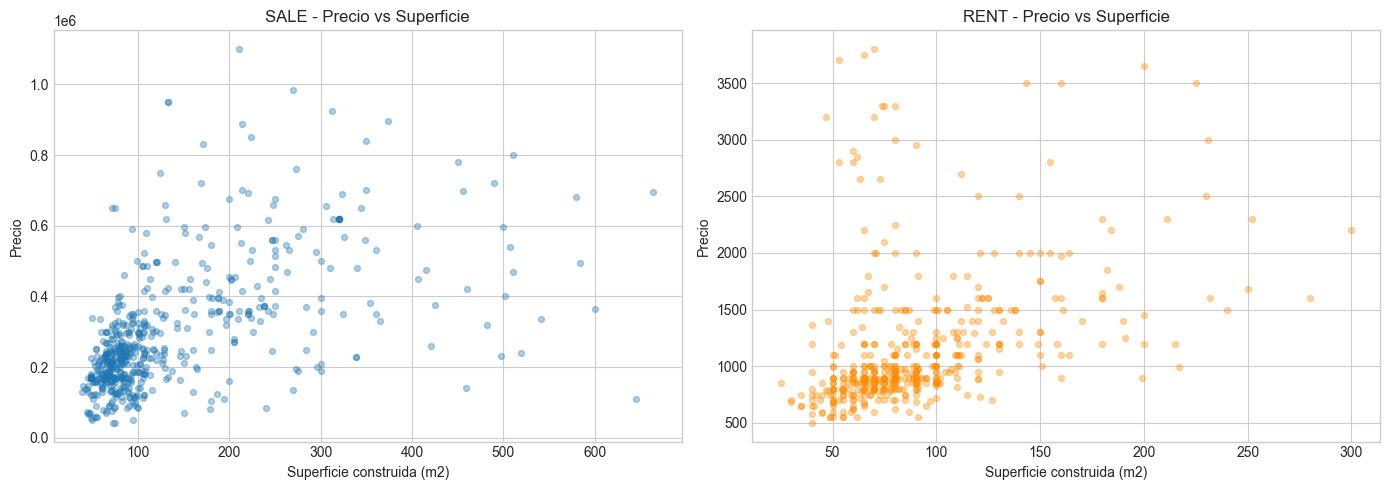

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sale_clean["superficie_construida_m2"], sale_clean["precio"], alpha=0.35, s=18)
axes[0].set_title("SALE - Precio vs Superficie")
axes[0].set_xlabel("Superficie construida (m2)")
axes[0].set_ylabel("Precio")

axes[1].scatter(rent_clean["superficie_construida_m2"], rent_clean["precio"], alpha=0.35, s=18, color="darkorange")
axes[1].set_title("RENT - Precio vs Superficie")
axes[1].set_xlabel("Superficie construida (m2)")
axes[1].set_ylabel("Precio")

plt.tight_layout()
plt.show()